**TRAIN TRANSFORMS**

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
import numpy as np
import os


TRAIN_DIR = r"C:\Users\alann\OneDrive\Desktop\plantdisease\dataset\images\train"

VAL_DIR = r"C:\Users\alann\OneDrive\Desktop\plantdisease\dataset\images\val" 


norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]


train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(norm_mean, norm_std)
])


val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(norm_mean, norm_std)
])

LOAD THE DATASET

In [2]:
# Load the dataset
if os.path.exists(VAL_DIR):
    train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
    val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_transforms)
else:
    # Split training data 80/20 if no val folder exists
    full_dataset = datasets.ImageFolder(TRAIN_DIR)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_indices, val_indices = torch.utils.data.random_split(
        range(len(full_dataset)), [train_size, val_size]
    )
    
    # Create datasets with specific transforms
    train_dataset = Subset(datasets.ImageFolder(TRAIN_DIR, transform=train_transforms), train_indices)
    val_dataset = Subset(datasets.ImageFolder(TRAIN_DIR, transform=val_transforms), val_indices)

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Train samples: 43444
Validation samples: 10861


In [3]:
def create_sampler(dataset):
    # Get targets (labels) depending on whether it's a Subset or full ImageFolder
    if isinstance(dataset, Subset):
        targets = np.array(dataset.dataset.targets)[dataset.indices]
    else:
        targets = np.array(dataset.targets)
    
    # Calculate weight for each class
    class_sample_count = np.array([len(np.where(targets == t)[0]) for t in np.unique(targets)])
    weight = 1. / class_sample_count
    samples_weight = torch.from_numpy(np.array([weight[t] for t in targets]))
    
    return WeightedRandomSampler(samples_weight.type('torch.DoubleTensor'), len(samples_weight))

train_sampler = create_sampler(train_dataset)

DATALOADERS

In [4]:

train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    sampler=train_sampler, 
    num_workers=2, 
    pin_memory=True
)


val_loader = DataLoader(
    val_dataset, 
    batch_size=32, 
    shuffle=False, 
    num_workers=2, 
    pin_memory=True
)


images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")

Batch shape: torch.Size([32, 3, 224, 224])


In [5]:
train_images, train_labels = next(iter(train_loader))
val_images, val_labels = next(iter(val_loader))

print("TRAIN BATCH")
print("Images shape:", train_images.shape)
print("Labels shape:", train_labels.shape)
print("Dtype:", train_images.dtype)
print("Value range:", train_images.min().item(), train_images.max().item())

print("\nVAL BATCH")
print("Images shape:", val_images.shape)
print("Labels shape:", val_labels.shape)
print("Value range:", val_images.min().item(), val_images.max().item())


TRAIN BATCH
Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Dtype: torch.float32
Value range: -2.1179039478302 2.640000104904175

VAL BATCH
Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Value range: -2.1007792949676514 2.640000104904175


In [6]:
def denormalize(tensor, mean=norm_mean, std=norm_std):
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return torch.clamp(tensor, 0, 1)


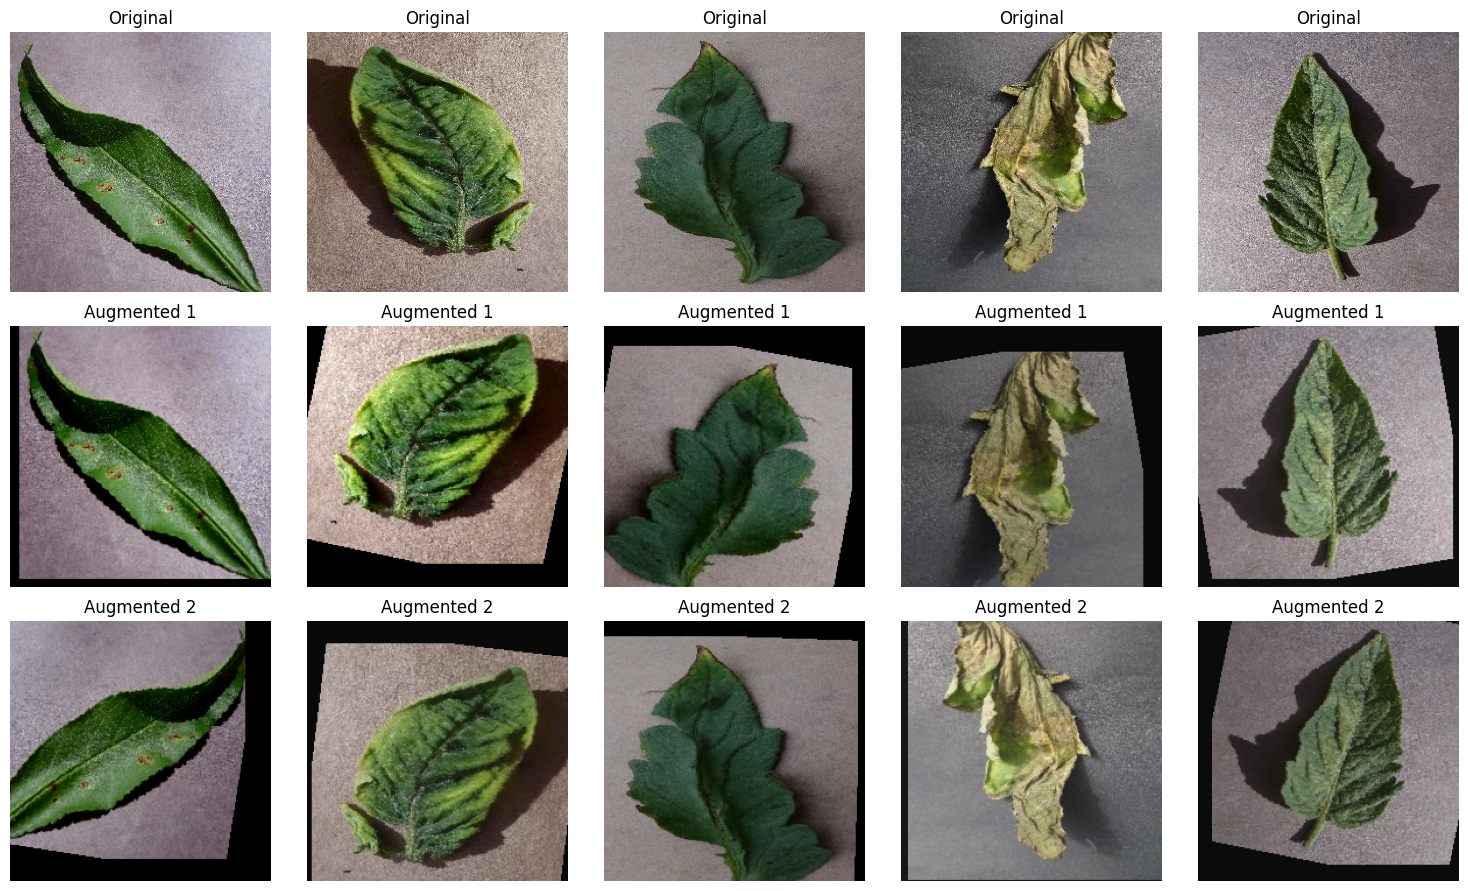

In [7]:
from PIL import Image
import matplotlib.pyplot as plt 
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

np.random.seed(42)
indices = np.random.choice(len(train_dataset), 5, replace=False)

for col, idx in enumerate(indices):
    img_path, _ = train_dataset.samples[idx]
    original = Image.open(img_path)

    axes[0, col].imshow(original)
    axes[0, col].set_title("Original")
    axes[0, col].axis("off")

    aug1 = denormalize(train_transforms(original).clone()).permute(1, 2, 0)
    axes[1, col].imshow(aug1)
    axes[1, col].set_title("Augmented 1")
    axes[1, col].axis("off")

    aug2 = denormalize(train_transforms(original).clone()).permute(1, 2, 0)
    axes[2, col].imshow(aug2)
    axes[2, col].set_title("Augmented 2")
    axes[2, col].axis("off")

plt.tight_layout()
plt.show()


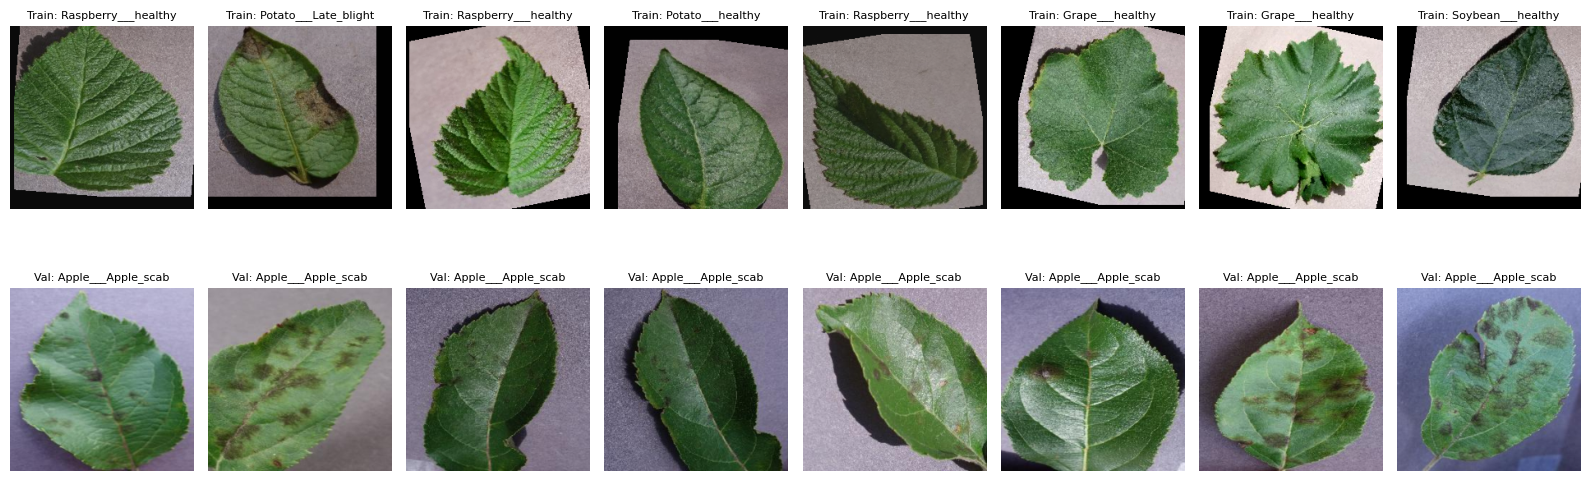

In [8]:
# 1. Define 'class_names' safely
if hasattr(train_dataset, 'classes'):
    class_names = train_dataset.classes
else:
    class_names = train_dataset.dataset.classes

# 2. Define 'denormalize' (Just in case it's missing)
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(tensor.device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(tensor.device)
    return tensor * std + mean

# 3. Your Plotting Code
fig, axes = plt.subplots(2, 8, figsize=(16, 6))

train_imgs, train_lbls = next(iter(train_loader))
val_imgs, val_lbls = next(iter(val_loader))

for i in range(8):
    # Train Images
    img = denormalize(train_imgs[i].clone()).permute(1, 2, 0).cpu().numpy()
    # Clip values to ensure they are valid for imshow (0..1)
    img = np.clip(img, 0, 1)
    
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Train: {class_names[train_lbls[i]]}", fontsize=8)
    axes[0, i].axis("off")

    # Val Images
    img = denormalize(val_imgs[i].clone()).permute(1, 2, 0).cpu().numpy()
    img = np.clip(img, 0, 1)
    
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Val: {class_names[val_lbls[i]]}", fontsize=8)
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")


if hasattr(train_dataset, 'classes'):
    num_classes = len(train_dataset.classes)
else:
    num_classes = len(train_dataset.dataset.classes)

print(f"Number of classes detected: {num_classes}")

Training on: cuda
Number of classes detected: 38


MLP

In [10]:
# --- Model 1: MLP (Simple Network) ---
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc_stack = nn.Sequential(
            nn.Linear(3 * 224 * 224, 256), 
            nn.ReLU(),
            nn.Dropout(0.2), 
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.fc_stack(x)
        return logits

CNN

In [11]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        logits = self.classifier(x)
        return logits

TRAIN AND VALIDATE


--- Training MLP Model ---

Epoch 1/7
Train Loss: 3.3897, Train Acc: 0.1172
Val   Loss: 3.6599, Val   Acc: 0.0977

Epoch 2/7
Train Loss: 2.6090, Train Acc: 0.2421
Val   Loss: 2.8855, Val   Acc: 0.2461

Epoch 3/7
Train Loss: 2.3942, Train Acc: 0.3047
Val   Loss: 3.0802, Val   Acc: 0.2270

Epoch 4/7
Train Loss: 2.2913, Train Acc: 0.3259
Val   Loss: 2.9975, Val   Acc: 0.2419

Epoch 5/7
Train Loss: 2.2530, Train Acc: 0.3380
Val   Loss: 3.8028, Val   Acc: 0.2090

Epoch 6/7
Train Loss: 2.2384, Train Acc: 0.3463
Val   Loss: 3.2108, Val   Acc: 0.2352

Epoch 7/7
Train Loss: 2.2091, Train Acc: 0.3562
Val   Loss: 3.2473, Val   Acc: 0.2588

MLP Model Training Complete!


--- Training CNN Model ---

Epoch 1/7
Train Loss: 1.8657, Train Acc: 0.4552
Val   Loss: 0.7716, Val   Acc: 0.7628

Epoch 2/7
Train Loss: 0.8655, Train Acc: 0.7357
Val   Loss: 0.4833, Val   Acc: 0.8549

Epoch 3/7
Train Loss: 0.6291, Train Acc: 0.8068
Val   Loss: 0.3400, Val   Acc: 0.8917

Epoch 4/7
Train Loss: 0.4997, Train Acc: 0

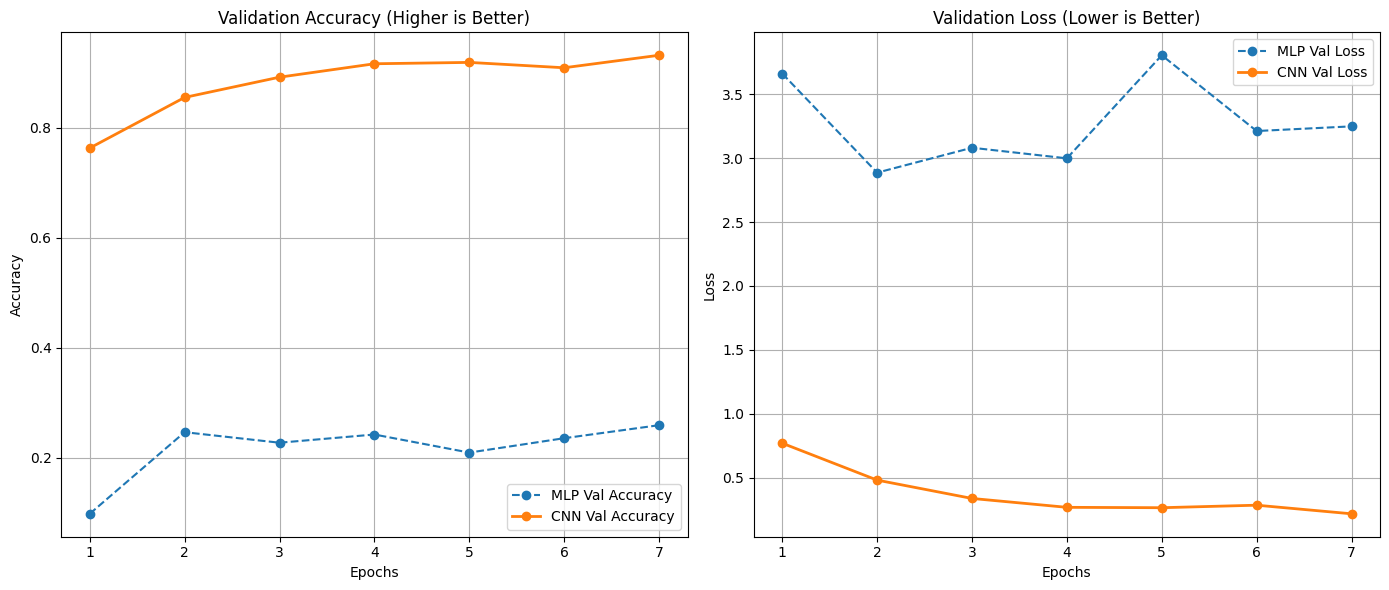

In [12]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

def train_and_evaluate(model, model_name, num_epochs=7):
    print(f"\n--- Training {model_name} ---")
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        
        model.train()
        train_loss_sum = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            train_loss_sum += loss.item() * images.size(0)
            train_correct += torch.sum(preds == labels)
            train_total += labels.size(0)

        train_loss = train_loss_sum / train_total
        train_acc = train_correct.double() / train_total

       
        model.eval()
        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                _, preds = torch.max(outputs, 1)
                val_loss_sum += loss.item() * images.size(0)
                val_correct += torch.sum(preds == labels)
                val_total += labels.size(0)

        val_loss = val_loss_sum / val_total
        val_acc = val_correct.double() / val_total

        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.4f}")

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc.item())
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc.item())

    print(f"\n{model_name} Training Complete!\n")
    return history



mlp_model = MLP()
mlp_history = train_and_evaluate(mlp_model, "MLP Model", num_epochs=7)


cnn_model = SimpleCNN()
cnn_history = train_and_evaluate(cnn_model, "CNN Model", num_epochs=7)



epochs = range(1, len(mlp_history['train_acc']) + 1)

plt.figure(figsize=(14, 6))

# -------- Accuracy --------
plt.subplot(1, 2, 1)
plt.plot(epochs, mlp_history['val_acc'], marker='o', linestyle='--', label='MLP Val Accuracy')
plt.plot(epochs, cnn_history['val_acc'], marker='o', linewidth=2, label='CNN Val Accuracy')
plt.title('Validation Accuracy (Higher is Better)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# -------- Loss --------
plt.subplot(1, 2, 2)
plt.plot(epochs, mlp_history['val_loss'], marker='o', linestyle='--', label='MLP Val Loss')
plt.plot(epochs, cnn_history['val_loss'], marker='o', linewidth=2, label='CNN Val Loss')
plt.title('Validation Loss (Lower is Better)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Model Evaluation on Validation Samples

In [13]:
import numpy as np

def visualize_predictions(model, model_name, val_loader, class_names, num_images=6):
    model.eval()
    images_shown = 0

    plt.figure(figsize=(12, 6))
    print(f"\nSample Predictions using {model_name}:")

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            for i in range(images.size(0)):
                if images_shown >= num_images:
                    plt.show()
                    return

                img = images[i].cpu().squeeze()

                
                if img.dim() == 3:
                    img = img.permute(1, 2, 0)

                plt.subplot(2, 3, images_shown + 1)
                plt.imshow(img, cmap='gray')
                plt.axis('off')

                actual = class_names[labels[i].item()]
                predicted = class_names[preds[i].item()]

                color = "green" if actual == predicted else "red"
                plt.title(f"P: {predicted}\nA: {actual}", color=color)

                images_shown += 1



Sample Predictions using MLP Model:


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7582842..2.0996952].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7695861..1.6232493].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..1.7685405].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..1.6116778].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8952821..2.2009804].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.5528543].


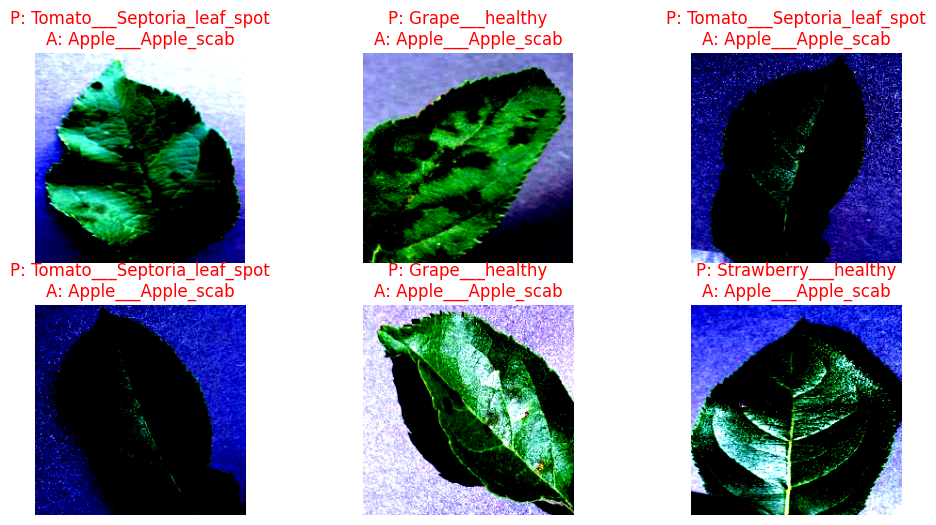


Sample Predictions using CNN Model:


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7582842..2.0996952].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7695861..1.6232493].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..1.7685405].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..1.6116778].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8952821..2.2009804].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.5528543].


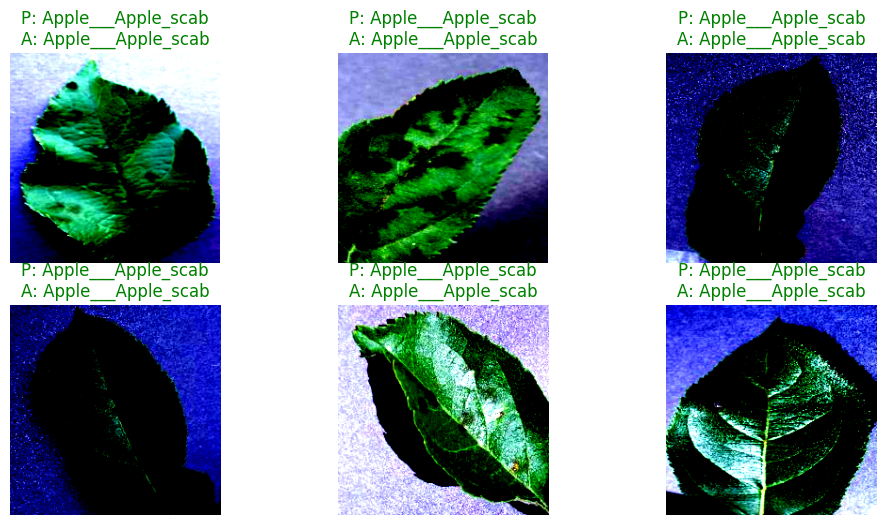

In [14]:
visualize_predictions(mlp_model, "MLP Model", val_loader, class_names)
visualize_predictions(cnn_model, "CNN Model", val_loader, class_names)


In [ ]:

mlp_best_acc = max(mlp_history['val_acc'])
cnn_best_acc = max(cnn_history['val_acc'])

print(f"Best MLP Validation Accuracy: {mlp_best_acc:.4f}")
print(f"Best CNN Validation Accuracy: {cnn_best_acc:.4f}")


Best MLP Validation Accuracy: 0.2588
Best CNN Validation Accuracy: 0.9316


In [ ]:
import torch


class_names = train_dataset.classes
num_classes = len(class_names)

if cnn_best_acc > mlp_best_acc:
    torch.save({
        'model_name': 'CNN',
        'model_state_dict': cnn_model.state_dict(),
        'class_names': class_names,
        'num_classes': num_classes
    }, "best_model.pth")
    best_model_name = "CNN"
else:
    torch.save({
        'model_name': 'MLP',
        'model_state_dict': mlp_model.state_dict(),
        'class_names': class_names,
        'num_classes': num_classes
    }, "best_model.pth")
    best_model_name = "MLP"

print(f"\nBest model selected: {best_model_name}")
print("Model saved properly as 'best_model.pth'")


Best model selected: CNN
Model saved properly as 'best_model.pth'
